# Hedging Vanilla FX Options

The baseline model used to price and hedge FX Option is the Garman–Kohlhagen model, which is the standard extension of Black–Scholes to FX options. The model is defined in the following way:

* Let $S_t$ = spot FX rate, quoted as *domestic currency per 1 unit of foreign currency*.
  (e.g. $S_t = 1.08 \,\text{USD/EUR}$).
* $r_d$ = domestic risk-free interest rate (e.g. USD OIS).
* $r_f$ = foreign risk-free interest rate (e.g. EUR OIS).
* $\sigma$ = constant volatility of FX rate.
* $T$ = maturity, $K$ = strike.

Under the **domestic risk-neutral measure** $\mathbb{Q}^d$:

$$
dS_t = (r_d - r_f) S_t \, dt + \sigma S_t \, dW_t^d, \\ 
dB_d(t) = r_d B_d(t)\, dt, \\ 
dB_f(t) = r_f B_f(t)\, dt
$$

In [218]:
from typing import List

import QuantLib as ql
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

Let initialize the global variables of the heding experiment. Let's assume that we are a UK based investor and we are buying a call option of the $EUR/GBP$ exchange rate (call $EUR$ put $GBP$), thus we have to delta hedge our position by shorting the €. In our case we have that

$$ 
\begin{align*}
S_0 &= 0.86265 \text{ the EUR/GBP spot rate at time } t = 0 \\
T &= 0.25 \\
r_f &= 0.02 \\
r_d &= 0.0397 \\
\end{align*}
$$

and we are going to hedge a $25\Delta$ call.

In [219]:
# Initialize Global variables
today = ql.Date(27, ql.August, 2025)
EUR_GBP = 0.86265
rf = 0.02
rd = 0.0397
EUR_GBP_QUOTE = ql.SimpleQuote(EUR_GBP)
GBP_EUR_QUOTE = ql.SimpleQuote(1 / EUR_GBP)
calendar = ql.JointCalendar(ql.Italy(), ql.UnitedKingdom())
dc = ql.Actual365Fixed()
spot_handle = ql.QuoteHandle(EUR_GBP_QUOTE)
expiration_date = today + ql.Period(3, ql.Months)
expiration_time = dc.yearFraction(today, expiration_date)
domestic_rf_handle = ql.YieldTermStructureHandle(ql.FlatForward(today, rd, dc))
foreign_rf_handle = ql.YieldTermStructureHandle(ql.FlatForward(today, rf, dc))

# Setting the global evaluation date
ql.Settings.instance().evaluationDate = today

Setting up the Discount curves

In [220]:
eur_dates = [ql.Date(27, ql.August, 2025), ql.Date(27, ql.August, 2026), ql.Date(27, ql.August, 2027)]
eur_dfs = [1.0, 0.98, 0.95]
eur_curve = ql.DiscountCurve(eur_dates, eur_dfs, ql.Actual365Fixed())
eur_curve.enableExtrapolation()

gbp_dates = [ql.Date(27, ql.August, 2025), ql.Date(27, ql.August, 2026), ql.Date(27, ql.August, 2027)]
gbp_dfs = [1.0, 0.985, 0.96]
gbp_curve = ql.DiscountCurve(gbp_dates, gbp_dfs, ql.Actual365Fixed())
gbp_curve.enableExtrapolation()

In [221]:
class FxVanillaOptionFactory:
    """
    Helper class used to create Vanilla FX Options and related objects used to price those
    """

    def __init__(self, spot: ql.QuoteHandle, expiry: ql.Date, option_type: ql.Option):
        self.exercise_ = ql.EuropeanExercise(expiry)
        self.option_type_ = option_type
        self.spot_ = spot
    
    def get_option(self, strike: float) -> ql.VanillaOption:
        payoff = ql.PlainVanillaPayoff(self.option_type_, strike)
        return ql.VanillaOption(payoff, self.exercise_)
    
    def get_gk_process(self, 
                       domesitc_ts_handle: ql.YieldTermStructureHandle, 
                       foreign_ts_handle: ql.YieldTermStructureHandle, 
                       vol_handle: ql.BlackVolTermStructureHandle):
        """
        Construct and return a QuantLib Garman-Kohlhagen process for FX option pricing.

        Parameters:
            domesitc_ts_handle (ql.YieldTermStructureHandle): The yield term structure handle for the domestic (quote) currency.
            foreign_ts_handle (ql.YieldTermStructureHandle): The yield term structure handle for the foreign (base) currency.
            vol_handle (ql.BlackVolTermStructureHandle): The Black volatility term structure handle for the FX rate.

        Returns:
            ql.GarmanKohlagenProcess: The stochastic process object used for pricing FX options under the Garman-Kohlhagen model.
        """
        return ql.GarmanKohlagenProcess(
            self.spot_,
            foreign_ts_handle,
            domesitc_ts_handle,
            vol_handle
        )
    
    @staticmethod
    def assign_analyitcal_price_engine(option, process):
        engine = ql.AnalyticEuropeanEngine(process)
        option.setPricingEngine(engine)

In [222]:
def create_vol_matrix(smile_vols):
    """Convert a 2D list of smile volatilities into a QuantLib Matrix for use in BlackVarianceSurface."""
    rows = len(smile_vols)
    cols = len(smile_vols[0])

    vol_matrix = ql.Matrix(cols, rows)

    for i in range(0, rows, 1):
        for j in range(0, cols, 1):
            vol_matrix[j][i] = smile_vols[i][j]
    return vol_matrix

def gen_path(process: ql.StochasticProcess, T: float, n: int, n_samples: int) -> List[List[float]]:
    """Generate sample paths for a given QuantLib stochastic process."""
    seq_gen = ql.GaussianRandomSequenceGenerator(ql.UniformRandomSequenceGenerator(n, ql.UniformRandomGenerator()))
    path_gen = ql.GaussianPathGenerator(process, T, n, seq_gen, False)
    paths = []

    for _ in range(n_samples):
        path = path_gen.next().value()
        paths.append(list(path))

    return paths

From empirical market data we also know that the quoted IVs are not constant across different strikes and different time to expiration, let's assume that we also have the IVs surface data (strike-vol surface) and build `ql.BlackVolTermStructureHandle` that represents the surface.

In [223]:
# Define a FX vol smile using BlackVarianceSurface
smile_expiries = [today + ql.Period(i, ql.Months) for i in [1, 3, 6, 12]]
smile_times = [dc.yearFraction(today, d) for d in smile_expiries]
smile_strikes = [0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]
# Example vol matrix: higher vols for OTM, lower for ATM
smile_vols = [
    [0.18, 0.16, 0.14, 0.13, 0.12, 0.13, 0.14, 0.16, 0.18],  # 1M
    [0.17, 0.15, 0.13, 0.12, 0.11, 0.12, 0.13, 0.15, 0.17],  # 3M
    [0.16, 0.14, 0.12, 0.11, 0.10, 0.11, 0.12, 0.14, 0.16],  # 6M
    [0.15, 0.13, 0.11, 0.10, 0.09, 0.10, 0.11, 0.13, 0.15]   # 12M
]
vol_martix = create_vol_matrix(smile_vols)
vol_surface = ql.BlackVarianceSurface(today, ql.NullCalendar(), smile_expiries, smile_strikes, vol_martix, dc)
vol_surface.enableExtrapolation()
vol_handle = ql.BlackVolTermStructureHandle(vol_surface)

In [224]:
call_factory = FxVanillaOptionFactory(spot_handle, today + ql.Period(3, ql.Months), ql.Option.Call)
delta_cal = ql.BlackDeltaCalculator(
    ql.Option.Call, 
    ql.DeltaVolQuote.Spot, 
    EUR_GBP, 
    gbp_curve.discount(expiration_time), 
    eur_curve.discount(expiration_time), 
    np.sqrt(vol_surface.blackVariance(expiration_time, EUR_GBP)))

d25_strike = delta_cal.strikeFromDelta(0.25) # get the corrispondend strike for the 25-Delta

call_25d = call_factory.get_option(d25_strike) # get the corrispondend call option
gk_process = call_factory.get_gk_process(domestic_rf_handle, foreign_rf_handle, vol_handle)
FxVanillaOptionFactory.assign_analyitcal_price_engine(call_25d, gk_process)

# $\Delta$ Hedging

In [225]:
nominal = 1_000_000 # in £ since the dom is GBP
n_b_days = calendar.businessDaysBetween(today, expiration_date)
paths = gen_path(gk_process, expiration_time, n_b_days, 1)

fx_path = paths[0]
trading_days = [calendar.advance(today, ql.Period(i, ql.Days)) for i in range(0, calendar.businessDaysBetween(today, expiration_date) + 1)]
trading_times = [dc.yearFraction(today, date) for date in trading_days]

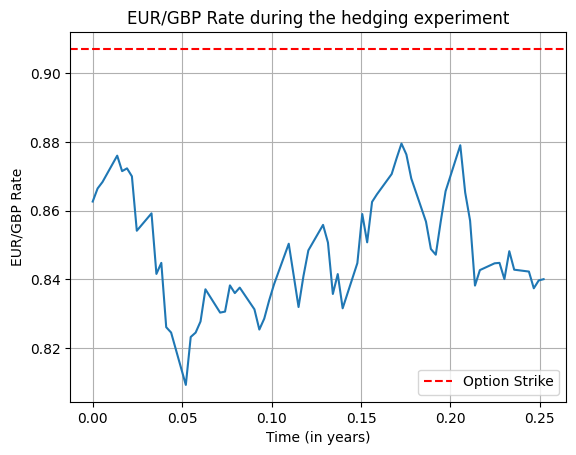

In [226]:
plt.plot(trading_times, fx_path)
plt.axhline(d25_strike, color='red', linestyle='--', label='Option Strike')
plt.title("EUR/GBP Rate during the hedging experiment")
plt.ylabel("EUR/GBP Rate")
plt.xlabel("Time (in years)")
plt.grid()
plt.legend()
plt.show()

In [227]:
# Helper function for the hedging loop
def change_eval_date(date: ql.Date):
    ql.Settings.instance().evaluationDate = date

def update_spot_fx_price(new_price: float):
    EUR_GBP_QUOTE.setValue(new_price)

def calc_hedging_portfolio_value(premium, short_for, long_dom):
    return premium - short_for * EUR_GBP_QUOTE.value() + long_dom

In our case we are long the call thus, in order to hedge our position, we need to short the underlying (with is €) and we also need to take into account the local bank account dynamic since it is part of the heding portfolio. The value of the hedging portfolio at time $t$ will be:

$$
\Pi_t = \underbrace{V_t}_{\text{option price}} - \overbrace{\Delta_{t-1} / S_t}^{\text{Short EUR}} + \overbrace{(\Delta_{t-1} - V_{t-1})}^{\text{GBP Bank account}} - \overbrace{(r_f * dt * S_{t})}^{\text{foreign cost in dom}} + \overbrace{(r_d * dt)}^{\text{domestic interest accrual}} 
$$

In [ ]:
def hedging_loop(
        option: ql.VanillaOption, 
        nominal: float, 
        spot_rate_quote: ql.QuoteHandle, 
        fx_path: List[float]
    ):   
    premium = option.NPV() * nominal
    short_eur = option.delta() * nominal / spot_rate_quote.value()
    premiums = [premium]
    short_eur_pos = [short_eur]
    cum_costs_gbp = [short_eur * spot_rate_quote.value() - premium]
    spot_rates = [spot_rate_quote.value()]
    deltas = [option.delta()]
    for_costs_dom = [0]
    dom_ints_accrs = [0]

    current_date = today
    current_delta = option.delta()

    # Delta hedging loop
    for i in range(1, n_b_days):
        prev_date = current_date
        prev_delta = current_delta
        current_date = calendar.advance(prev_date, ql.Period(1, ql.Days))
        dt = dc.yearFraction(prev_date, current_date)
        S = fx_path[i]

        change_eval_date(current_date)
        update_spot_fx_price(S)

        new_premium = option.NPV() * nominal
        for_cost_dom = short_eur * rf * dt
        dom_int_accr = cum_costs_gbp[-1] * rd * dt
        current_delta = option.delta()
        d_delta = current_delta - prev_delta
        new_short_eur = current_delta * nominal / S
        
        premiums.append(new_premium)
        short_eur_pos.append(new_short_eur)
        cum_costs_gbp.append(cum_costs_gbp[-1] + dom_int_accr - for_cost_dom + nominal * d_delta)
        deltas.append(current_delta)
        spot_rates.append(S)
        for_costs_dom.append(for_cost_dom)
        dom_ints_accrs.append(dom_int_accr)

        short_eur = new_short_eur

    hedging_df = pd.DataFrame(
        {
            "spot_rate": spot_rates,
            "deltas": deltas,
            "premium": premiums,
            "short_€_pos": short_eur_pos,
            "for_cost_dom": for_costs_dom,
            "dom_int_accr": dom_ints_accrs,
            "cum_costs_gbp": cum_costs_gbp
        }
    )

    return hedging_df

In [229]:
hedging_res = hedging_loop(call_25d, nominal, EUR_GBP_QUOTE, fx_path)

In [230]:
hedging_res

,spot_rate,deltas,premium,short_€_pos,for_cost_dom,dom_int_accr,cum_costs_gbp,gbp_bank_account
0,0.862650,0.250489,8081.026584,290371.922326,0.000000,0.000000,242408.312210,242408.312210
1,0.866457,0.272614,9076.540750,314631.161160,15.910790,26.366055,264543.871728,242418.786645
2,0.868345,0.283892,9601.651514,326934.434973,17.240064,26.367194,275832.683035,242427.923568
3,0.876015,0.331595,11960.396150,378526.136597,53.742647,79.104564,323571.804483,242453.327273
4,0.871504,0.303199,10529.098071,347903.035736,20.741158,26.370951,295190.715550,242458.932319
...,...,...,...,...,...,...,...,...
61,0.848186,0.175087,5020.650731,206425.431541,9.091420,26.498262,167640.931952,243641.253421
62,0.842799,0.150864,4143.736467,179003.119607,11.310983,26.500158,143424.407782,243656.422181
63,0.842256,0.148542,4062.403407,176362.583888,29.425170,79.505424,141120.522797,243706.500480
64,0.837379,0.128716,3387.086724,153712.558488,9.663703,26.507255,121299.479922,243723.327429


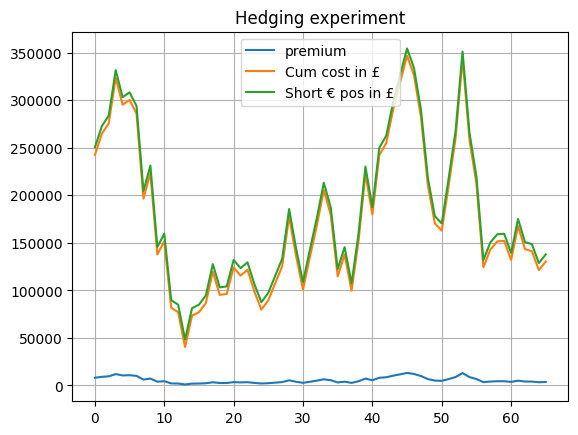

In [257]:
plt.plot(hedging_res["premium"].values, label='premium')
plt.plot(hedging_res["cum_costs_gbp"].values, label='Cum cost in £')
plt.plot(hedging_res["short_€_pos"].values * hedging_res["spot_rate"].values, label='Short € pos in £')
plt.title("Hedging experiment")
plt.legend()
plt.grid()
plt.show()

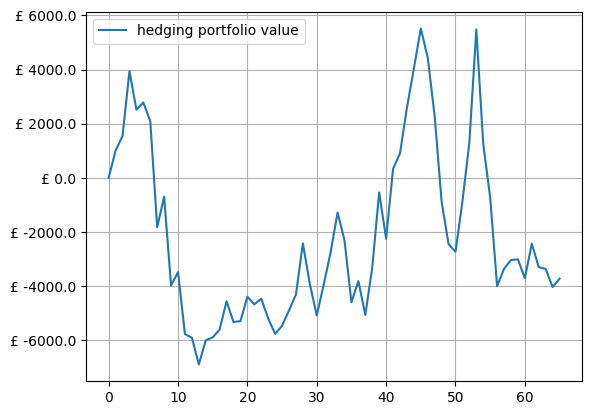

In [253]:
hedging_portfolio_value = hedging_res["premium"] + hedging_res["cum_costs_gbp"] - hedging_res["short_€_pos"] * hedging_res["spot_rate"].values

fig, ax = plt.subplots()

ax.plot(hedging_portfolio_value, label='hedging portfolio value')
ax.yaxis.set_major_formatter(lambda x, z : f"£ {x}")
plt.legend()
plt.grid()
plt.show()

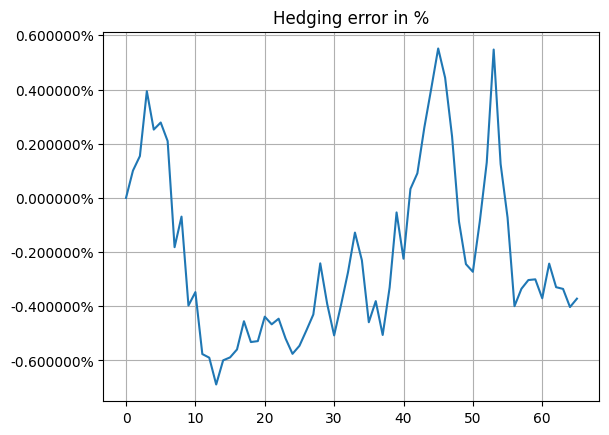

In [256]:
fig, ax = plt.subplots()

ax.plot((hedging_portfolio_value / nominal) * 100)
ax.yaxis.set_major_formatter(lambda x, z : f"{x:2f}%")
ax.set_title("Hedging error in %")
plt.grid()
plt.show()